In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os,sys
sys.path.insert(0,"..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import torchxrayvision as xrv

`CheXlocalize_Dataset` follows the same `pathology_masks` interface as `NIH_Dataset`, `VinBrain_Dataset`, and `SIIM_Pneumothorax_Dataset`: `sample["pathology_masks"]` is a sparse dict keyed by pathology index, each value a `(1, H, W)` array.

In [5]:
dataset_path = "/Users/ieee8023/data/"

In [6]:
def plot_sample_with_masks(sample, df):
    width = len(sample["pathology_masks"])
    fig, axs = plt.subplots(1, max(2,1+width), sharey=True, figsize=(3+3*width,3))
    #axs[0].imshow(sample["img"][0], cmap="Greys_r");
    axs[0].set_title("idx:" + str(sample["idx"]))
    for i, patho in enumerate(sample["pathology_masks"].keys()):
        #axs[i+1].imshow(sample["img"][0], cmap="Greys_r");
        axs[i+1].imshow(sample["pathology_masks"][patho][0]+1, alpha=0.5);
        axs[i+1].set_title(df.pathologies[patho])
    plt.show()

In [7]:
d_chexlocalize = xrv.datasets.CheXlocalize_Dataset(
    imgpath=os.path.join(dataset_path, "CheXpert-v1.0-small/"),
    csvpath=os.path.join(dataset_path, "CheXpert-v1.0-small/valid.csv"),
    pathology_masks=True,
    segmentation_jsonpath=os.path.join(dataset_path, "CheXpert-v1.0-small/gt_segmentations_val.json"))

In [8]:
d_chexlocalize.csv.has_masks.value_counts()

has_masks
True     170
False     30
Name: count, dtype: int64

In [ ]:
# Plotted without images due to license

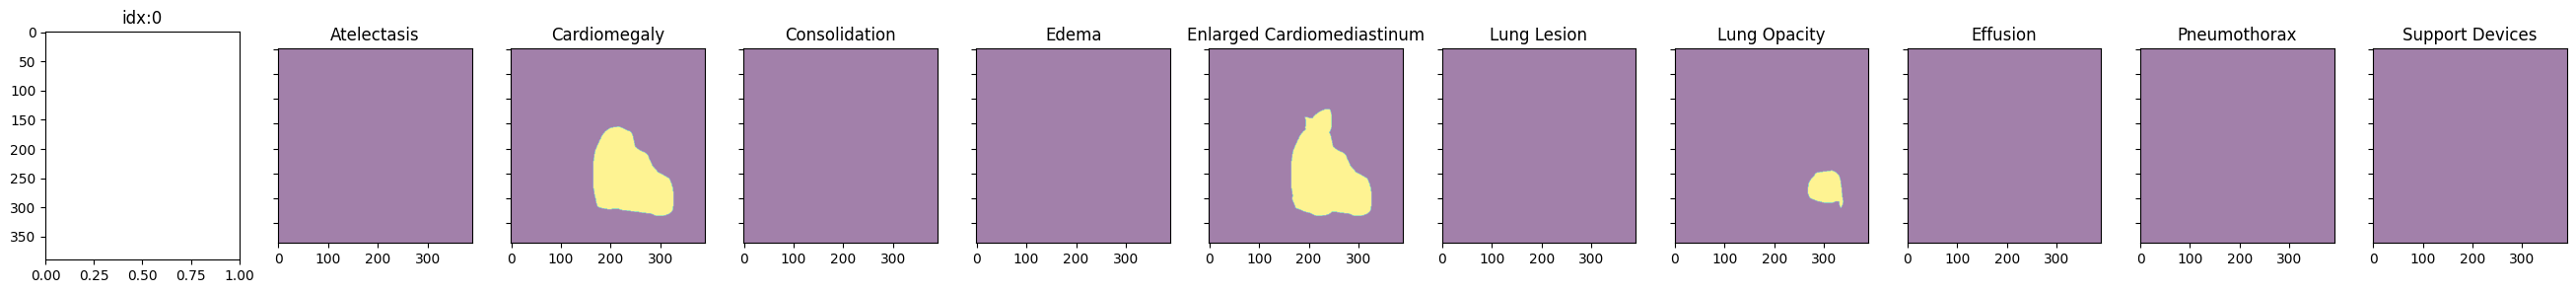

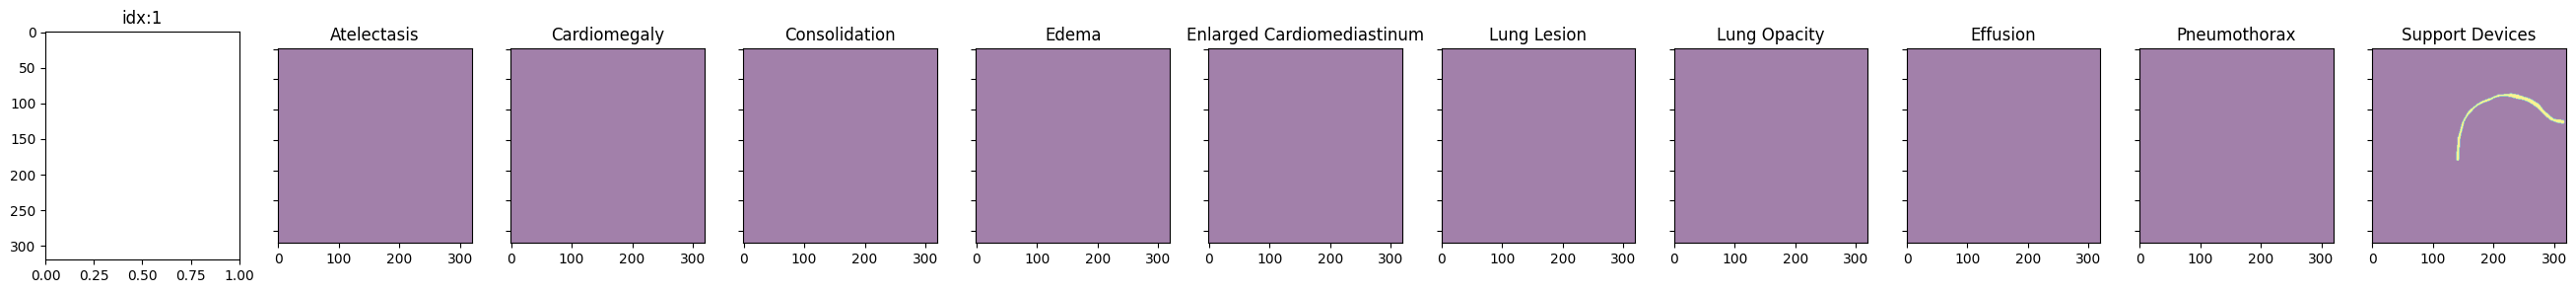

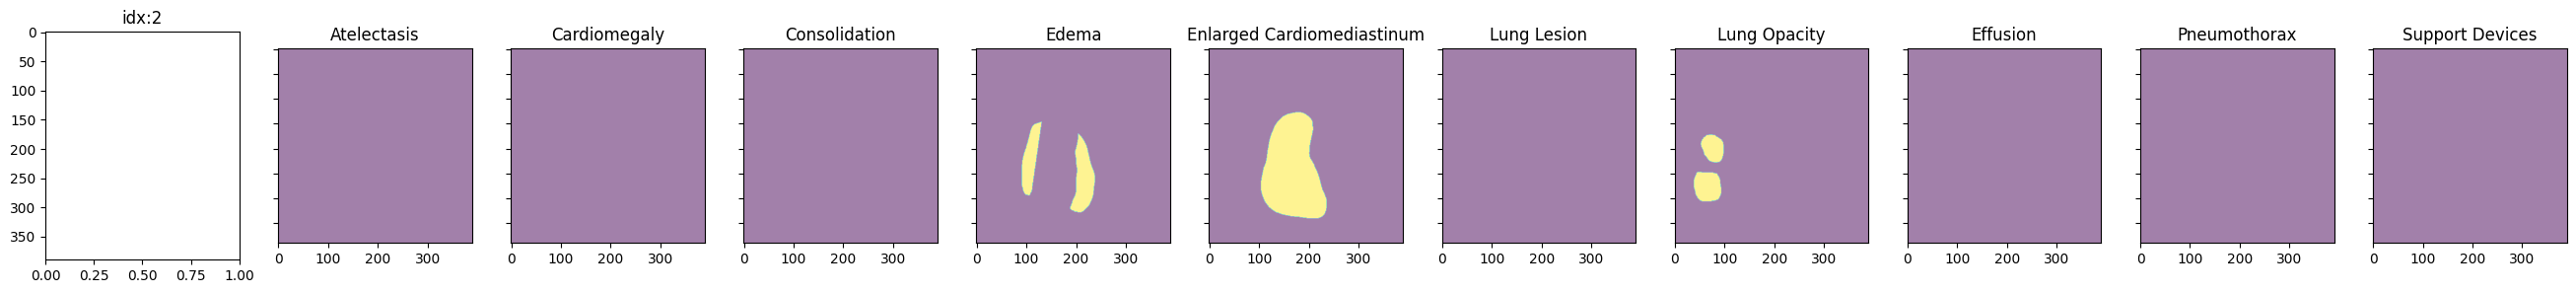

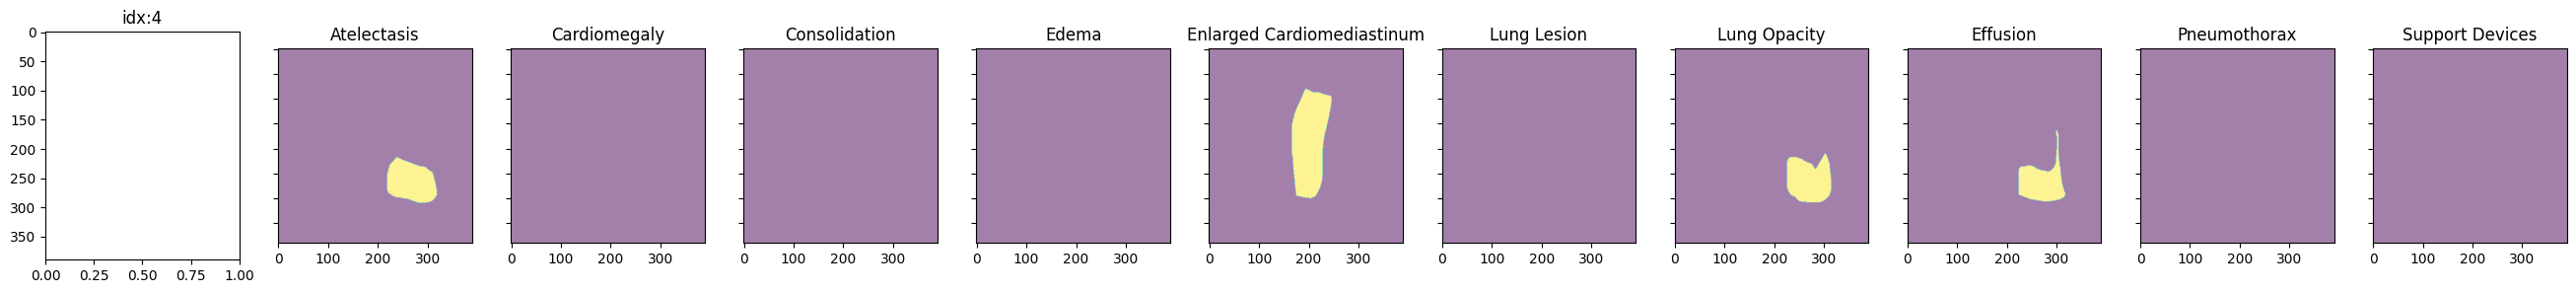

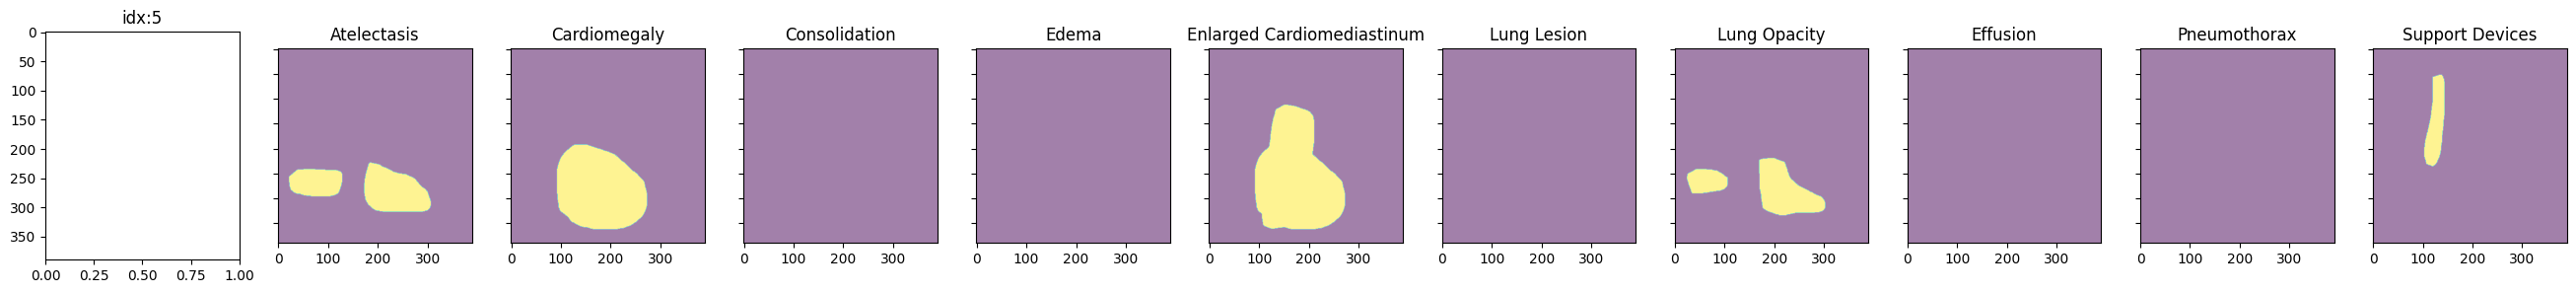

In [10]:
for idx in np.where(d_chexlocalize.csv.has_masks)[0][:5]:
    sample = d_chexlocalize[idx]
    if len(sample["pathology_masks"]) > 0:
        plot_sample_with_masks(sample, d_chexlocalize)